# 6단계: 시계열분석 (생활, 화장품) — 필수 티어: 도메인 단위 Prophet

**분석 단위**: 도메인 전체 월별 집계(단위1). 상품 단위(단위2, 전역 DL 모델)는 권장 티어로 별도 노트북에서 다룬다.

**타겟 변수**: 월별 부정 리뷰 비율 (`GeneralPolarity == -1`인 리뷰 수 / 그 달 전체 리뷰 수)

**ML/DL 구분**: Prophet은 추세(trend) + 계절성(seasonality) + 변곡점(changepoint)을 통계적으로 분해하는 기법이다. 신경망이 아니다 (`docs/05_06단계_가이드.md` 참고).

**데이터 제약**: 생활·화장품 모두 SNS 출처 리뷰에는 RDate가 없다(원본 자체에 필드 없음). 도메인 전체 기준으로는 각각 90.0%/89.9%가 RDate를 갖고 있어 (`docs/데이터_구조.md` 3-1절), 날짜 있는 리뷰만 사용해도 표본이 충분하다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import os

os.makedirs("../results/figures", exist_ok=True)

reviews = pd.read_parquet("../data/processed/reviews.parquet")
DOMAINS = ["생활", "화장품"]
print(reviews["RDate_parsed"].notna().sum(), "/", len(reviews), "행에 RDate 있음")

C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


211804 / 225283 행에 RDate 있음


In [2]:
plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 깨짐 방지 (Windows 기본 한글 폰트)
plt.rcParams["axes.unicode_minus"] = False

In [3]:
def monthly_negative_ratio(domain: str) -> pd.DataFrame:
    sub = reviews[(reviews["Domain"] == domain) & reviews["RDate_parsed"].notna()].copy()
    sub["month"] = sub["RDate_parsed"].dt.to_period("M").dt.to_timestamp()
    g = sub.groupby("month").agg(
        total=("review_id", "count"),
        negative=("GeneralPolarity", lambda s: (s == -1).sum()),
    )
    g["neg_ratio"] = g["negative"] / g["total"]
    return g.reset_index()

series = {dom: monthly_negative_ratio(dom) for dom in DOMAINS}
for dom, s in series.items():
    print(f"[{dom}] {len(s)}개월치, 기간 {s['month'].min().date()} ~ {s['month'].max().date()}, "
          f"월평균 리뷰수 {s['total'].mean():.0f}건, 부정비율 평균 {s['neg_ratio'].mean()*100:.1f}%")

[생활] 85개월치, 기간 2015-05-01 ~ 2022-10-01, 월평균 리뷰수 475건, 부정비율 평균 11.6%
[화장품] 80개월치, 기간 2016-01-01 ~ 2022-08-01, 월평균 리뷰수 506건, 부정비율 평균 23.7%


In [4]:
# 최근 데이터가 너무 적은 달(리뷰 수가 극단적으로 적은 달)이 있으면 Prophet이 잡음을 추세로 오인할 수 있으니 확인
for dom, s in series.items():
    thin_months = s[s["total"] < 10]
    print(f"[{dom}] 월간 리뷰 10건 미만인 달: {len(thin_months)}개 / 전체 {len(s)}개월")
    if len(thin_months) > 0:
        print(thin_months[["month", "total"]].to_string(index=False))

[생활] 월간 리뷰 10건 미만인 달: 3개 / 전체 85개월
     month  total
2015-05-01      1
2015-06-01      2
2015-11-01      1
[화장품] 월간 리뷰 10건 미만인 달: 1개 / 전체 80개월
     month  total
2016-01-01      8


In [5]:
def run_prophet(domain: str, s: pd.DataFrame):
    df = s[["month", "neg_ratio"]].rename(columns={"month": "ds", "neg_ratio": "y"})

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,  # 월별 집계라 변곡점을 너무 민감하게 잡지 않도록 기본값(0.05)보다 약간 완화
    )
    m.fit(df)

    future = m.make_future_dataframe(periods=3, freq="MS")
    forecast = m.predict(future)

    # 유의미한 변곡점: prophet이 추정한 delta(추세 기울기 변화량)가 작지 않은 것만
    deltas = m.params["delta"].mean(axis=0)
    sig_idx = [i for i, d in enumerate(deltas) if abs(d) >= 0.01]
    sig_changepoints = [(m.changepoints.iloc[i], deltas[i]) for i in sig_idx]

    fig = m.plot(forecast)
    ax = fig.gca()
    for cp, d in sig_changepoints:
        ax.axvline(cp, color="red", linestyle="--", alpha=0.6)
    ax.set_title(f"{domain} - 월별 부정비율 추세/예측 (빨간선 = 유의미한 변곡점)")
    fig.savefig(f"../results/figures/06_시계열_{domain}_조.png", dpi=120, bbox_inches="tight")
    plt.show()

    return m, forecast, sig_changepoints

## 생활

13:06:19 - cmdstanpy - INFO - Chain [1] start processing


13:06:19 - cmdstanpy - INFO - Chain [1] done processing


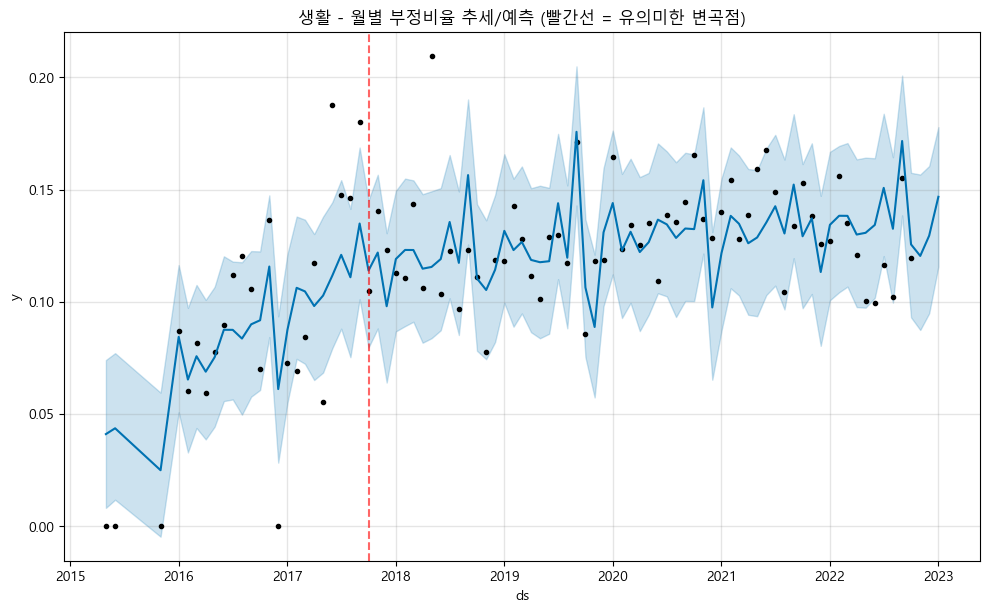

유의미한 변곡점 1개:
  2017-10-01 | 기울기 변화량 -0.8942 | 기울기가 아래쪽으로 꺾임(-)


In [6]:
m_생활, fc_생활, cps_생활 = run_prophet("생활", series["생활"])
print(f"유의미한 변곡점 {len(cps_생활)}개:")
for cp, d in cps_생활:
    # delta는 기울기 변화량이지 "부정비율이 실제로 좋아졌다/나빠졌다"가 아님 -- 상승세가 꺾여도 여전히
    # 상승 중일 수 있고, 하락세가 완만해져도 여전히 하락 중일 수 있음. 방향 해석은 그래프를 직접 보고 판단할 것.
    direction = "기울기가 위쪽으로 꺾임(+)" if d > 0 else "기울기가 아래쪽으로 꺾임(-)"
    print(f"  {cp.date()} | 기울기 변화량 {d:+.4f} | {direction}")

### 3-1. 정정: MCMC로 변곡점 통계적 유의성 재검증 (2026-08-19 추가)

위에서 고른 변곡점(delta 점추정치가 가장 큰 시점)이 통계적으로 유의미한지, `mcmc_samples`를 켜서 각 delta의 95% 신뢰구간을 직접 구한다 (손이 패션 도메인에서 쓴 것과 동일한 방법). 구간이 0을 포함하면 "노이즈로도 설명 가능하다"는 뜻이라 유의미하다고 말할 수 없다.

In [7]:
import numpy as np

df_생활 = series["생활"][["month", "neg_ratio"]].rename(columns={"month": "ds", "neg_ratio": "y"})
m_생활_mcmc = Prophet(
    yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
    changepoint_prior_scale=0.1, mcmc_samples=300,
)
m_생활_mcmc.fit(df_생활)

delta_samples = m_생활_mcmc.params["delta"]  # shape: (mcmc_samples, n_changepoints)
ci_rows = []
for i, cp in enumerate(m_생활_mcmc.changepoints):
    lo, mid, hi = np.percentile(delta_samples[:, i], [2.5, 50, 97.5])
    ci_rows.append({"changepoint": cp, "delta_median": mid, "ci_low": lo, "ci_high": hi,
                     "0포함안함(유의)": (lo > 0) or (hi < 0)})
ci_df_생활 = pd.DataFrame(ci_rows).sort_values("delta_median", key=lambda s: s.abs(), ascending=False)

n_sig = ci_df_생활["0포함안함(유의)"].sum()
print(f"[생활] 95% CI가 0을 포함하지 않는(통계적으로 유의미한) 변곡점: {n_sig}개 / 전체 {len(ci_df_생활)}개 후보")
print(ci_df_생활.head(8).to_string(index=False))

13:06:20 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

...

chain 4: 100%|██████████| 300/300 [00:01<00:00, 182.39it/s, (Sampling completed)]

chain 4: 100%|██████████| 300/300 [00:01<00:00, 157.26it/s, (Sampling completed)]


13:06:22 - cmdstanpy - INFO - CmdStan done processing.


13:06:22 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!



[생활] 95% CI가 0을 포함하지 않는(통계적으로 유의미한) 변곡점: 0개 / 전체 25개 후보
changepoint  delta_median    ci_low  ci_high  0포함안함(유의)
 2017-07-01     -0.080809 -0.641789 0.172569      False
 2017-10-01     -0.080392 -0.599952 0.178557      False
 2017-05-01     -0.074096 -0.552246 0.205651      False
 2018-01-01     -0.062602 -0.387837 0.159215      False
 2018-03-01     -0.060909 -0.545644 0.163098      False
 2018-06-01     -0.050141 -0.406696 0.208581      False
 2017-02-01     -0.043321 -0.455908 0.162580      False
 2016-11-01     -0.034958 -0.427839 0.202434      False


## 화장품

13:06:22 - cmdstanpy - INFO - Chain [1] start processing


13:06:22 - cmdstanpy - INFO - Chain [1] done processing


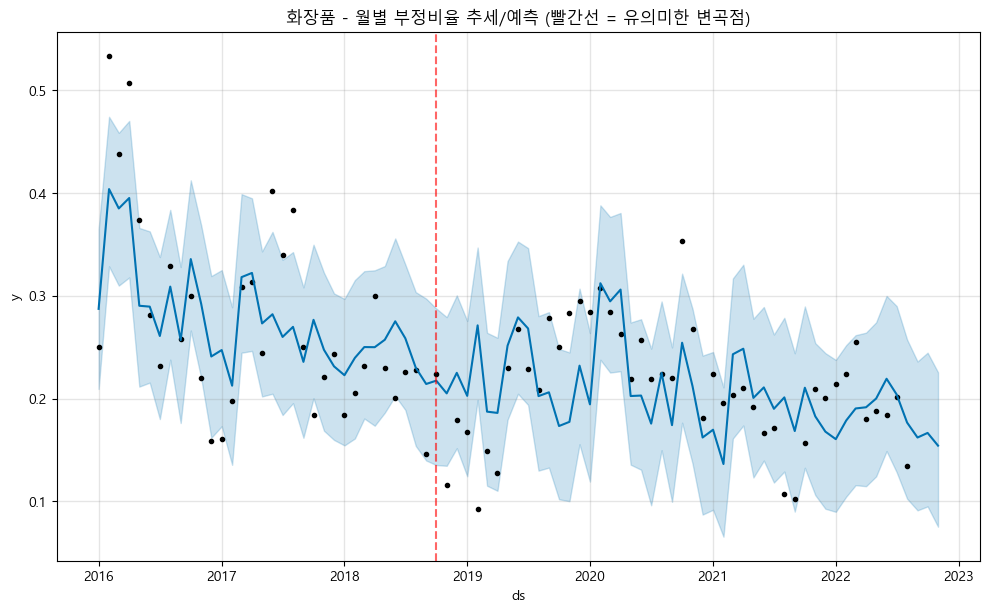

유의미한 변곡점 1개:
  2018-10-01 | 기울기 변화량 +0.1853 | 기울기가 위쪽으로 꺾임(+)


In [8]:
m_화장품, fc_화장품, cps_화장품 = run_prophet("화장품", series["화장품"])
print(f"유의미한 변곡점 {len(cps_화장품)}개:")
for cp, d in cps_화장품:
    direction = "기울기가 위쪽으로 꺾임(+)" if d > 0 else "기울기가 아래쪽으로 꺾임(-)"
    print(f"  {cp.date()} | 기울기 변화량 {d:+.4f} | {direction}")

### 3-1 (계속). 화장품도 동일하게 MCMC 재검증

In [9]:
df_화장품 = series["화장품"][["month", "neg_ratio"]].rename(columns={"month": "ds", "neg_ratio": "y"})
m_화장품_mcmc = Prophet(
    yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
    changepoint_prior_scale=0.1, mcmc_samples=300,
)
m_화장품_mcmc.fit(df_화장품)

delta_samples = m_화장품_mcmc.params["delta"]
ci_rows = []
for i, cp in enumerate(m_화장품_mcmc.changepoints):
    lo, mid, hi = np.percentile(delta_samples[:, i], [2.5, 50, 97.5])
    ci_rows.append({"changepoint": cp, "delta_median": mid, "ci_low": lo, "ci_high": hi,
                     "0포함안함(유의)": (lo > 0) or (hi < 0)})
ci_df_화장품 = pd.DataFrame(ci_rows).sort_values("delta_median", key=lambda s: s.abs(), ascending=False)

n_sig = ci_df_화장품["0포함안함(유의)"].sum()
print(f"[화장품] 95% CI가 0을 포함하지 않는(통계적으로 유의미한) 변곡점: {n_sig}개 / 전체 {len(ci_df_화장품)}개 후보")
print(ci_df_화장품.head(8).to_string(index=False))

13:06:23 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

...

chain 4: 100%|██████████| 300/300 [00:01<00:00, 163.96it/s, (Sampling completed)]

chain 4: 100%|██████████| 300/300 [00:01<00:00, 154.90it/s, (Sampling completed)]


13:06:24 - cmdstanpy - INFO - CmdStan done processing.


13:06:25 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_id_glm_lpdf: Scale vector is inf, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Exception: normal_id_glm_lpdf: Scale vector is 0, but must be positive finite! (in 'prophet.stan', line 137, column 2 to line 142, column 4)
Consider re-running with show_console=True if the above output is unclear!



[화장품] 95% CI가 0을 포함하지 않는(통계적으로 유의미한) 변곡점: 0개 / 전체 25개 후보
changepoint  delta_median    ci_low  ci_high  0포함안함(유의)
 2018-07-01      0.048593 -0.190916 0.456669      False
 2018-10-01      0.046776 -0.159868 0.458372      False
 2018-05-01      0.046165 -0.188795 0.417123      False
 2018-02-01      0.044295 -0.220345 0.472722      False
 2018-12-01      0.040454 -0.185994 0.440145      False
 2020-08-01     -0.032979 -0.415395 0.223010      False
 2019-03-01      0.031963 -0.205292 0.422380      False
 2020-11-01     -0.031139 -0.337202 0.196411      False
